# Order Book Analysis & Market Making

Analyzes live order book snapshots + deltas (Apr 18-20, 2026) to understand:
- Bid-ask spread by market series
- Depth at top of book
- Book imbalance as a directional signal
- Market making feasibility

**Key finding:** KXNBAPTS median spread $0.03 (81% of snapshots profitable after fees).
Imbalance signal is inconclusive (corr -0.04, n=112). Only ~30 hours of data — needs
more collection before conclusions are reliable.

In [1]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 2. Order Book Analysis

Using live order book snapshots + deltas to understand:
- Typical bid-ask spread (can we execute passively?)
- Depth at top of book (how much size can we trade?)
- Book imbalance as a directional signal

### Background: Order Books and Kalshi Binary Contracts

**What is an order book?** An order book is a list of all outstanding buy and sell orders for a given contract, organized by price. Buyers post **bids** (the most they will pay), sellers post **asks** (the least they will accept), and a trade happens whenever a new order matches an existing one. The "best bid" is the highest bid; the "best ask" is the lowest ask. The gap between them is the **bid-ask spread** — you can always sell immediately at the best bid or buy immediately at the best ask, but you pay the spread as a cost of immediacy.

**How Kalshi maps to a traditional order book.** A Kalshi contract is a binary claim that pays $1 if an event happens (YES) and $0 if it does not. The order book has two sides: bids on the YES contract and bids on the NO contract. Because YES and NO are complements — if YES is worth $0.60, NO is worth $0.40 — a bid of $0.40 for NO is economically identical to an ask of $0.60 for YES. The code below uses this identity: `best_yes_ask = 1.0 - best_no_bid`. This means every order, regardless of which side it was placed on, can be expressed as a price for the YES contract, giving us a single unified book.

**Yes/No symmetry.** Every Kalshi market has exactly two outcomes. If you think the Lakers will win at 65% but the YES contract trades at $0.55, you can buy YES. Equivalently, if NO trades at $0.45, that implies the same YES price. This symmetry means depth on the NO side is effectively ask-side depth for YES. The `yes_depth` and `no_depth` columns in the parsed data below reflect this: they measure resting order size on each side of the book, not directional sentiment per se.

**Subscription-time snapshots.** The snapshots in bronze were captured at the moment the WebSocket subscribed to each market's book channel. They are **not** continuous — they show the book's state at one point in time, then deltas update it. This notebook only uses the initial snapshots, which limits how much we can say about book dynamics over time.

In [2]:
# Load order book snapshots from materialized Parquet
# (Run `python -m scripts.materialize.bronze_to_parquet` to refresh)
import pyarrow.parquet as pq
import io

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_snapshot.parquet")
snap_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
snap_df["t_receipt_dt"] = pd.to_datetime(snap_df["t_receipt"], unit="s", utc=True)

# Derive bid_depth_top from yes_book_json (size at the best bid level)
def _top_bid_size(book_json):
    if pd.isna(book_json):
        return 0
    levels = json.loads(book_json)
    if not levels:
        return 0
    best = max(levels, key=lambda x: float(x[0]))
    return float(best[1])

snap_df["bid_depth_top"] = snap_df["yes_book_json"].apply(_top_bid_size)

print(f"Loaded {len(snap_df)} order book snapshots across {snap_df['ticker'].nunique()} tickers")
print(f"Time range: {snap_df['t_receipt_dt'].min()} to {snap_df['t_receipt_dt'].max()}")

# Keep raw snapshot keys for the raw-format demo cell
paginator = s3.get_paginator("list_objects_v2")
snap_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/orderbook_snapshot/"):
    snap_keys.extend([o["Key"] for o in page.get("Contents", [])])
print(f"Bronze snapshot files (for raw demo): {len(snap_keys)}")


Loaded 6705 order book snapshots across 991 tickers
Time range: 2026-04-18 23:21:03.750926256+00:00 to 2026-04-21 04:32:19.581380367+00:00
Bronze snapshot files (for raw demo): 45


### Raw snapshot format (bronze)

Each line in `bronze/kalshi_ws/orderbook_snapshot/*.jsonl.gz` is a JSON record captured at WebSocket subscription time. The full structure:

| Field | Example | Description |
|---|---|---|
| `source` | `"kalshi_ws"` | Always `kalshi_ws` — identifies the ingestion pipeline. |
| `channel` | `"orderbook_snapshot"` | Always `orderbook_snapshot` — distinguishes from `orderbook_delta` and `trade` channels. |
| `t_receipt` | `1776554463.75` | Unix timestamp (seconds, nanosecond precision) when our WS client received this frame. This is our clock, not Kalshi's — includes network latency. |
| `frame.type` | `"orderbook_snapshot"` | Kalshi WS message type. Snapshots arrive once per subscription; deltas follow. |
| `frame.sid` | `1` | Subscription ID — which WS subscription produced this frame. Useful for debugging reconnects. |
| `frame.seq` | `1` | Sequence number within the subscription. Monotonically increasing; gaps indicate missed frames. Critical for applying deltas in order. |
| `frame.msg.market_ticker` | `"KXNBAGAME-26APR18ATLNYK-ATL"` | Kalshi contract ticker (unique per contract). |
| `frame.msg.market_id` | `"883a9c4d-..."` | Kalshi internal UUID. Redundant with ticker for our purposes. |
| `frame.msg.yes_dollars_fp` | `[["0.30", "412088.33"], ...]` | **Full YES-side order book.** Array of `[price, size]` pairs in dollar strings, sorted by price ascending. Each entry is a resting bid to buy YES at that price. Size is in cents (e.g., `412088.33` = ~$4,120). |
| `frame.msg.no_dollars_fp` | `[["0.31", "250000.00"], ...]` | **Full NO-side order book.** Same format as above, but for NO bids. A NO bid at $X is economically equivalent to a YES ask at $(1-X). |

**YES/NO duality:** `yes_dollars_fp` is the bid side for YES. `no_dollars_fp` is the bid side for NO, which is the **ask side for YES** (since YES + NO = $1.00). To get the best YES ask: `1.0 - max(no_prices)`.

**What the parsing code below drops:** `source`, `channel`, `frame.type` (constants), `frame.sid`, `frame.seq` (subscription metadata), `frame.msg.market_id` (redundant with ticker), and the **full level-by-level book** — collapsing it into summary stats (`best_bid`, `best_ask`, `spread`, `yes_depth`, `no_depth`, `bid_depth_top`, level counts).

In [3]:
# Show a single raw snapshot record from bronze
sample_key = snap_keys[0]
obj = s3.get_object(Bucket=S3_BUCKET, Key=sample_key)
raw = gzip.decompress(obj["Body"].read()).decode()
first_record = json.loads(raw.strip().split("\n")[0])

# Truncate the level arrays for display (show first 3 levels only)
display_rec = {
    "source": first_record["source"],
    "channel": first_record["channel"],
    "t_receipt": first_record["t_receipt"],
    "frame": {
        "type": first_record["frame"]["type"],
        "sid": first_record["frame"]["sid"],
        "seq": first_record["frame"]["seq"],
        "msg": {
            "market_ticker": first_record["frame"]["msg"]["market_ticker"],
            "market_id": first_record["frame"]["msg"]["market_id"],
            "yes_dollars_fp": first_record["frame"]["msg"]["yes_dollars_fp"][:3] + ["... (truncated)"],
            "no_dollars_fp": first_record["frame"]["msg"]["no_dollars_fp"][:3] + ["... (truncated)"],
        }
    }
}

yes_levels = first_record["frame"]["msg"]["yes_dollars_fp"]
no_levels = first_record["frame"]["msg"]["no_dollars_fp"]
print(json.dumps(display_rec, indent=2))
print(f"\nFull book depth: {len(yes_levels)} YES levels, {len(no_levels)} NO levels")

{
  "source": "kalshi_ws",
  "channel": "orderbook_snapshot",
  "t_receipt": 1776554463.7509263,
  "frame": {
    "type": "orderbook_snapshot",
    "sid": 1,
    "seq": 1,
    "msg": {
      "market_ticker": "KXNBAGAME-26APR18ATLNYK-ATL",
      "market_id": "883a9c4d-2d4c-434b-83e7-a77097119936",
      "yes_dollars_fp": [
        [
          "0.0100",
          "2840934.00"
        ],
        [
          "0.0200",
          "15604.00"
        ],
        [
          "0.0300",
          "573234.00"
        ],
        "... (truncated)"
      ],
      "no_dollars_fp": [
        [
          "0.0100",
          "2958416.94"
        ],
        [
          "0.0200",
          "35553.00"
        ],
        [
          "0.0300",
          "380484.00"
        ],
        "... (truncated)"
      ]
    }
  }
}

Full book depth: 30 YES levels, 66 NO levels


### Order book snapshot table columns

| Column | Description |
|---|---|
| `t_receipt` | Unix timestamp when the WebSocket client received this snapshot |
| `ticker` | Kalshi market ticker (e.g., `KXNBAGAME-26APR18ATLNYK-ATL`) |
| `best_bid` | Highest resting YES bid price. This is the most you can sell YES for immediately. |
| `best_ask` | Lowest implied YES ask price, computed as `1.0 - best_no_bid`. A NO bid of $0.30 means someone will pay $0.30 for the contract to *not* happen — equivalently, they're offering YES at $0.70. |
| `spread` | `best_ask - best_bid`. The cost of immediacy — crossing the spread by market-buying and immediately market-selling costs you this amount. |
| `yes_depth` | Total dollar volume of all resting YES bids across all price levels. Measures how much you could sell into before exhausting the bid side. |
| `no_depth` | Total dollar volume of all resting NO bids (= YES ask-side depth). Measures how much you could buy (YES) before exhausting the ask side. |
| `bid_depth_top` | Dollar volume at the single best YES bid level. Often much smaller than `yes_depth` — if you need to sell more than this, you'll walk the book and get worse prices. |
| `n_yes_levels` | Number of distinct price levels with resting YES bids (book depth on the bid side). |
| `n_no_levels` | Number of distinct price levels with resting NO bids (book depth on the ask side for YES). |
| `imbalance` | `(yes_depth - no_depth) / (yes_depth + no_depth + 1)`. Ranges from -1 (all depth on ask/NO side) to +1 (all depth on bid/YES side). Positive values suggest latent buying pressure. |

**Note on units:** `yes_depth`, `no_depth`, and `bid_depth_top` are in dollar-cents (Kalshi's native unit) — the large values (e.g., 5,849,174) are cents, i.e., ~$58k of resting bids.

In [4]:
snap_df.head()

,t_receipt,conn_id,sid,seq,ticker,best_bid,best_ask,spread,yes_depth,no_depth,n_yes_levels,n_no_levels,yes_book_json,no_book_json,t_receipt_dt,bid_depth_top
0,1.776554e+09,NaN,1,1,KXNBAGAME-26APR18ATLNYK-ATL,0.30,0.31,0.01,5849174.21,6433999.42,30,66,"[[""0.0100"", ""2840934.00""], [""0.0200"", ""15604.0...","[[""0.0100"", ""2958416.94""], [""0.0200"", ""35553.0...",2026-04-18 23:21:03.750926256+00:00,412088.33
1,1.776554e+09,NaN,1,2,KXNBAGAME-26APR18ATLNYK-NYK,0.69,0.70,0.01,6939284.58,7414301.97,69,30,"[[""0.0100"", ""2964844.00""], [""0.0200"", ""9504.00...","[[""0.0100"", ""2816725.00""], [""0.0200"", ""35553.0...",2026-04-18 23:21:03.751263380+00:00,10674.96
2,1.776554e+09,NaN,1,3,KXNBAGAME-26APR18HOULAL-HOU,0.57,0.58,0.01,5113737.74,11451112.99,57,42,"[[""0.0100"", ""3023838.00""], [""0.0200"", ""10104.0...","[[""0.0100"", ""2751954.00""], [""0.0200"", ""5673.00...",2026-04-18 23:21:03.751364470+00:00,24824.16
3,1.776554e+09,NaN,1,4,KXNBAGAME-26APR18HOULAL-LAL,0.42,0.43,0.01,5110808.04,5999922.40,42,54,"[[""0.0100"", ""2778157.00""], [""0.0200"", ""10104.0...","[[""0.0100"", ""3018041.00""], [""0.0200"", ""5673.00...",2026-04-18 23:21:03.751443386+00:00,10302.00
4,1.776554e+09,NaN,1,5,KXNBAGAME-26APR19ORLDET-DET,0.76,0.77,0.01,4969913.76,5331204.09,73,23,"[[""0.0100"", ""2921330.00""], [""0.0200"", ""6400.00...","[[""0.0100"", ""2958866.00""], [""0.0200"", ""10597.0...",2026-04-18 23:21:03.763458252+00:00,1988.00


### Background: Bid-Ask Spread and Liquidity

**What the spread tells you.** The bid-ask spread is the cost of transacting immediately. A $0.03 spread on a YES contract means if you buy at the ask and instantly sell at the bid, you lose 3 cents. Tighter spreads mean cheaper execution — the market is more **liquid**. Wider spreads mean someone (usually a market maker) is demanding more compensation for providing that immediacy.

**What drives spreads.** Three forces widen spreads: (1) **Low competition** — fewer market makers posting quotes means less pressure to tighten. (2) **Volatility** — if the true probability can shift quickly (e.g., during a live NBA game), makers widen to avoid being picked off by stale quotes. (3) **Information asymmetry** — if some traders have better information (e.g., they are watching the game with lower latency), makers widen to compensate for the expected losses to those informed traders. This last force is called **adverse selection** and is the central risk in market making.

**Why spreads differ across series.** Player prop markets (KXNBAPTS, KXNBAREB, etc.) tend to have wider spreads than game-level markets (KXNBAGAME) for a structural reason: there are far more player prop tickers (every player x game x threshold), so market maker attention and capital is spread thinner. Game-level markets attract more volume and more maker competition, which compresses spreads. The bar chart below shows this pattern directly.

BID-ASK SPREAD ANALYSIS
  Valid observations: 6705
  Mean spread: $0.0476
  Median spread: $0.0300
  p25: $0.0200
  p75: $0.0400
  Spread <= $0.01: 6.0%
  Spread <= $0.02: 28.6%
  Spread <= $0.03: 50.8%

Spread by market series:
  KXNBAGAME      : median $0.020, mean $0.032, n=952
  KXNBAPTS       : median $0.040, mean $0.055, n=3484
  KXNBASPREAD    : median $0.020, mean $0.028, n=1113
  KXNBATOTAL     : median $0.020, mean $0.056, n=1156

TOP-OF-BOOK DEPTH (yes side):
  Mean: $5,325
  Median: $362


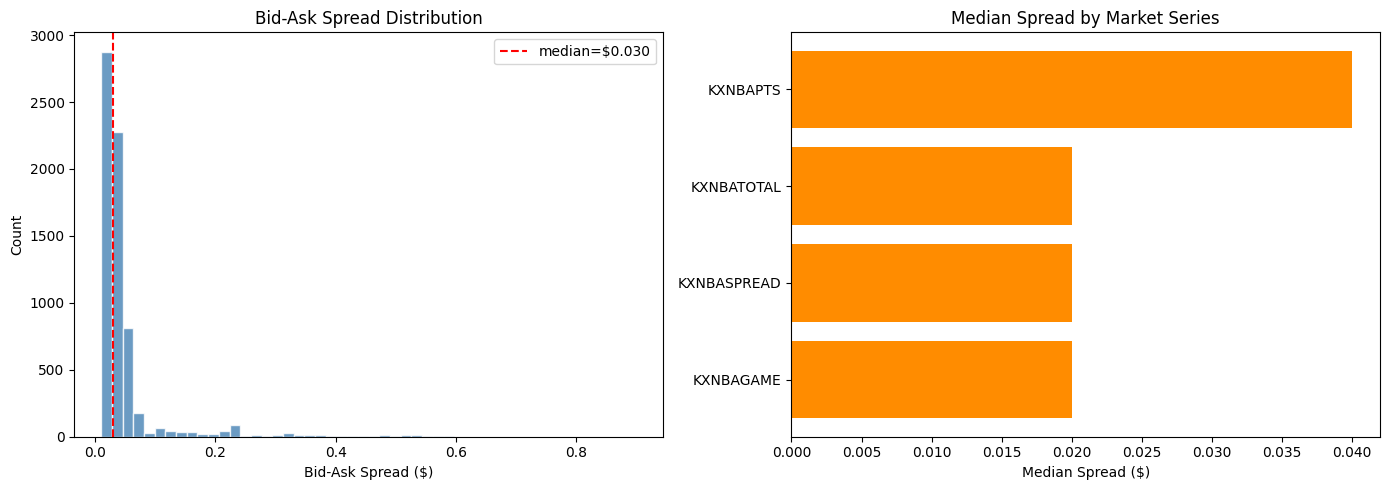

In [5]:
valid_spreads = snap_df[snap_df["spread"].notna() & (snap_df["spread"] > 0)]
print("BID-ASK SPREAD ANALYSIS")
print("=" * 60)
print(f"  Valid observations: {len(valid_spreads)}")
print(f"  Mean spread: ${valid_spreads['spread'].mean():.4f}")
print(f"  Median spread: ${valid_spreads['spread'].median():.4f}")
print(f"  p25: ${valid_spreads['spread'].quantile(0.25):.4f}")
print(f"  p75: ${valid_spreads['spread'].quantile(0.75):.4f}")
print(f"  Spread <= $0.01: {(valid_spreads['spread'] <= 0.01).mean():.1%}")
print(f"  Spread <= $0.02: {(valid_spreads['spread'] <= 0.02).mean():.1%}")
print(f"  Spread <= $0.03: {(valid_spreads['spread'] <= 0.03).mean():.1%}")

# By market type (GAME vs SPREAD vs TOTAL vs player props)
valid_spreads = valid_spreads.copy()
valid_spreads["series"] = valid_spreads["ticker"].apply(
    lambda t: re.match(r"(KXNBA\w+?)-", t).group(1) if re.match(r"(KXNBA\w+?)-", t) else "unknown"
)
print(f"\nSpread by market series:")
for series, grp in valid_spreads.groupby("series"):
    print(f"  {series:15s}: median ${grp['spread'].median():.3f}, "
          f"mean ${grp['spread'].mean():.3f}, n={len(grp)}")

# Depth at top of book
print(f"\nTOP-OF-BOOK DEPTH (yes side):")
print(f"  Mean: ${valid_spreads['bid_depth_top'].mean():,.0f}")
print(f"  Median: ${valid_spreads['bid_depth_top'].median():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(valid_spreads["spread"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(valid_spreads["spread"].median(), color="red", linestyle="--", 
                label=f"median=${valid_spreads['spread'].median():.3f}")
axes[0].set_xlabel("Bid-Ask Spread ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bid-Ask Spread Distribution")
axes[0].legend()

# Spread by series
series_medians = valid_spreads.groupby("series")["spread"].median().sort_values()
axes[1].barh(series_medians.index, series_medians.values, color="darkorange")
axes[1].set_xlabel("Median Spread ($)")
axes[1].set_title("Median Spread by Market Series")
plt.tight_layout()
plt.show()

In [6]:
# Order book imbalance as directional signal
# Imbalance = (yes_depth - no_depth) / (yes_depth + no_depth)
# Hypothesis: when yes side is thicker, price is more likely to move up (more buyers waiting)

snap_df["imbalance"] = (snap_df["yes_depth"] - snap_df["no_depth"]) / (snap_df["yes_depth"] + snap_df["no_depth"] + 1)

# Load WS trades from materialized Parquet
print("Loading live WS trades from materialized Parquet...")
obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/trade.parquet")
ws_trades_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
ws_trades_df["t_receipt_dt"] = pd.to_datetime(ws_trades_df["t_receipt"], unit="s", utc=True)
print(f"Loaded {len(ws_trades_df):,} WS trades across {ws_trades_df['ticker'].nunique()} tickers")


Loading live WS trades from materialized Parquet...
Loaded 878,767 WS trades across 803 tickers


### Background: Order Book Imbalance as a Directional Signal

**The idea.** Order book imbalance measures whether resting buy orders outweigh resting sell orders. The formula here is `(yes_depth - no_depth) / (yes_depth + no_depth + 1)`, which ranges from -1 (all depth on the NO/ask side) to +1 (all depth on the YES/bid side). The hypothesis is that if more volume is resting on the bid side, there is latent buying pressure that predicts upward price movement.

**What the literature says.** In equity markets, order book imbalance is a well-documented short-term predictor of price changes — see Cont, Kukanov & Stoikov (2014), "The Price Impact of Order Book Events." The mechanism is straightforward: if bid depth exceeds ask depth, incoming market orders are more likely to hit the ask (consuming it) than the bid, pushing the price up. The signal is strongest at very short horizons (seconds to minutes) and decays as the book rebalances.

**Why it might not work here.** Three reasons for caution in prediction markets: (1) **Thin books** — with only a few dollars of depth at each level, a single order can flip the imbalance sign, making it noisy. (2) **Snapshot sparsity** — the code below uses subscription-time snapshots, not a continuously reconstructed book. By the time the snapshot is taken, the book state may have already been arbitraged away. A proper test needs delta-by-delta book reconstruction to measure imbalance at the moment before each trade. (3) **Small sample** — the notebook header notes n=112 observations and correlation of -0.04. That is indistinguishable from noise. The 5-minute window also dilutes any short-horizon signal that might exist.

**Interpreting the results.** A correlation near zero with a small sample does not mean imbalance has no signal — it means this dataset cannot detect one. The scatter plot below will likely show a cloud with no visible trend. The right next step is continuous book reconstruction from deltas, not concluding the signal is absent.

Tickers in both snapshots and trades: 790
Snapshot time range: 2026-04-18 23:21:03.750926256+00:00 to 2026-04-21 04:32:19.581380367+00:00
Trade time range:    2026-04-19 00:15:13.696224451+00:00 to 2026-04-21 04:48:22.162687063+00:00

Imbalance → price movement (5-min window): 697 observations

Price movement by imbalance bin (5 bins):
Bin    Mean Imb     Mean Move    N     
----------------------------------------
0      -0.805       0.0171       140   
1      -0.193       0.0006       139   
2      -0.060       0.0030       139   
3      0.059        0.0018       139   
4      0.754        -0.0072      140   

Correlation(imbalance, 5m_price_move): -0.0762
  (positive = yes-heavy book predicts price going up)


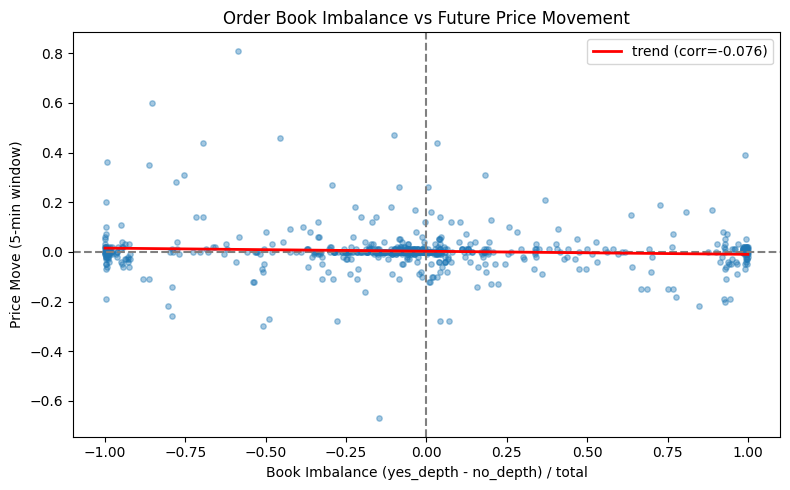

In [7]:
# For each ticker in snapshots, measure price movement in the 30s after the snapshot
# Join: for each snapshot, find trades in the next 30 seconds for the same ticker

# Only analyze tickers present in both snapshots and trades
common_tickers = set(snap_df["ticker"]) & set(ws_trades_df["ticker"])
print(f"Tickers in both snapshots and trades: {len(common_tickers)}")

# Debug: check time overlap between snapshots and trades
snap_time_range = (snap_df["t_receipt"].min(), snap_df["t_receipt"].max())
trade_time_range = (ws_trades_df["t_receipt"].min(), ws_trades_df["t_receipt"].max())
print(f"Snapshot time range: {pd.to_datetime(snap_time_range[0], unit='s', utc=True)} to {pd.to_datetime(snap_time_range[1], unit='s', utc=True)}")
print(f"Trade time range:    {pd.to_datetime(trade_time_range[0], unit='s', utc=True)} to {pd.to_datetime(trade_time_range[1], unit='s', utc=True)}")

# The snapshots are taken at subscription time, so they're sparse in time.
# Widen the window: look for trades within 5 MINUTES after each snapshot (not 30s)
# This measures medium-term price direction vs book state at subscription.

imbalance_results = []
for ticker in list(common_tickers):
    tk_snaps = snap_df[snap_df["ticker"] == ticker].sort_values("t_receipt")
    tk_trades = ws_trades_df[ws_trades_df["ticker"] == ticker].sort_values("t_receipt")
    
    if tk_trades.empty or tk_snaps.empty:
        continue
    
    for _, snap in tk_snaps.iterrows():
        t0 = snap["t_receipt"]
        # Find trades in [t0, t0+300s] (5 minutes)
        future_trades = tk_trades[(tk_trades["t_receipt"] > t0) & 
                                   (tk_trades["t_receipt"] <= t0 + 300)]
        if len(future_trades) < 2:
            continue
        
        # Price movement = last trade in window vs first trade
        price_first = future_trades["yes_price"].iloc[0]
        price_last = future_trades["yes_price"].iloc[-1]
        
        if price_first and price_last:
            # Use mid-price if available, else best_bid
            mid = (snap["best_bid"] + snap["best_ask"]) / 2 if snap["best_ask"] else snap["best_bid"]
            imbalance_results.append({
                "ticker": ticker,
                "imbalance": snap["imbalance"],
                "spread": snap["spread"],
                "price_move": price_last - price_first,
                "mid_to_last": price_last - mid if mid else None,
                "n_trades_5m": len(future_trades),
            })

imb_df = pd.DataFrame(imbalance_results)
print(f"\nImbalance → price movement (5-min window): {len(imb_df)} observations")

if len(imb_df) >= 10:
    # Bin by imbalance quintile
    n_bins = min(5, len(imb_df) // 3)
    imb_df["imb_bin"] = pd.qcut(imb_df["imbalance"], n_bins, labels=False, duplicates="drop")
    
    print(f"\nPrice movement by imbalance bin ({n_bins} bins):")
    print(f"{'Bin':<6} {'Mean Imb':<12} {'Mean Move':<12} {'N':<6}")
    print("-" * 40)
    for q, grp in imb_df.groupby("imb_bin"):
        print(f"{q:<6} {grp['imbalance'].mean():<12.3f} {grp['price_move'].mean():<12.4f} {len(grp):<6}")
    
    # Correlation
    corr = imb_df["imbalance"].corr(imb_df["price_move"])
    print(f"\nCorrelation(imbalance, 5m_price_move): {corr:.4f}")
    print(f"  (positive = yes-heavy book predicts price going up)")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(imb_df["imbalance"], imb_df["price_move"], alpha=0.4, s=15)
    ax.axhline(0, color="gray", linestyle="--")
    ax.axvline(0, color="gray", linestyle="--")
    # Trend line
    z = np.polyfit(imb_df["imbalance"], imb_df["price_move"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(imb_df["imbalance"].min(), imb_df["imbalance"].max(), 50)
    ax.plot(x_range, p(x_range), "r-", linewidth=2, label=f"trend (corr={corr:.3f})")
    ax.set_xlabel("Book Imbalance (yes_depth - no_depth) / total")
    ax.set_ylabel("Price Move (5-min window)")
    ax.set_title(f"Order Book Imbalance vs Future Price Movement")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif len(imb_df) > 0:
    print(f"\nOnly {len(imb_df)} observations — not enough for quintile analysis.")
    print(f"This is a data limitation: snapshots are sparse (only at WS subscription).")
    print(f"Need continuous book state reconstruction from deltas for proper analysis.")
else:
    print("\nNo valid observations — snapshot and trade time windows don't overlap.")
    print("Snapshots happen at subscription time; trades may come later.")
    print("Need to reconstruct book from deltas for continuous imbalance signal.")

In [8]:
# Market making profitability estimate
# If we can post at best_bid and best_ask and get filled on both sides,
# profit = spread - fee per round trip

# Estimate fill probability: how often does the price cross our posted level?
# Proxy: if a trade occurs at or below our posted bid (or at/above our ask) within N seconds

# For now, theoretical analysis:
valid_snap = snap_df[snap_df["spread"].notna() & (snap_df["spread"] > 0)].copy()
valid_snap["series"] = valid_snap["ticker"].apply(
    lambda t: re.match(r"(KXNBA\w+?)-", t).group(1) if re.match(r"(KXNBA\w+?)-", t) else "unknown"
)

print("MARKET MAKING FEASIBILITY")
print("=" * 60)
print(f"\nIf we capture the full spread and pay $0.02 fee per round-trip:")
print(f"  {'Series':<15} {'Med Spread':<12} {'Profit/RT':<12} {'% Profitable'}")
print(f"  {'-'*50}")

for series, grp in valid_snap.groupby("series"):
    med_spread = grp["spread"].median()
    profit = med_spread - 0.02
    pct_profitable = (grp["spread"] > 0.02).mean()
    print(f"  {series:<15} ${med_spread:.3f}       ${profit:.3f}       {pct_profitable:.0%}")

print(f"\n  NOTE: Assumes both legs fill (optimistic). Real fill rate depends on")
print(f"  adverse selection — you get filled when the market moves against you.")
print(f"  Net profit ≈ spread_captured × fill_rate - adverse_selection_cost")

MARKET MAKING FEASIBILITY

If we capture the full spread and pay $0.02 fee per round-trip:
  Series          Med Spread   Profit/RT    % Profitable
  --------------------------------------------------
  KXNBAGAME       $0.020       $0.000       59%
  KXNBAPTS        $0.040       $0.020       81%
  KXNBASPREAD     $0.020       $0.000       55%
  KXNBATOTAL      $0.020       $0.000       68%

  NOTE: Assumes both legs fill (optimistic). Real fill rate depends on
  adverse selection — you get filled when the market moves against you.
  Net profit ≈ spread_captured × fill_rate - adverse_selection_cost


### Background: Market Making Feasibility

**What is market making?** A market maker continuously posts both a bid and an ask, earning the spread when both sides fill. If you bid $0.55 and ask $0.58 on a YES contract, and both orders fill, you bought at $0.55 and sold at $0.58, netting $0.03 per contract before fees. The market maker does not need a view on the outcome — they profit from the spread, not from the contract settling YES or NO.

**Fees eat into the spread.** Kalshi charges a fee per contract (the code assumes $0.02 round-trip). If the spread is $0.03 and fees are $0.02, the theoretical profit per round-trip is only $0.01. The "% profitable" column below shows what fraction of observed snapshots had spreads wide enough to cover fees. This is a necessary condition for MM profitability, not a sufficient one.

**Adverse selection: the core risk.** You do not get filled at random — you get filled when someone *wants* to trade against you. If LeBron scores 8 points in the first quarter and the over/under shifts, an informed trader will hit your stale ask before you can cancel it. This is **adverse selection**: your fills are disproportionately concentrated in the moments when the market is moving against you. The result is that your *realized* spread capture is smaller than the *posted* spread, and can easily be negative. The `NOTE` in the output below flags this: `Net profit = spread_captured x fill_rate - adverse_selection_cost`.

**Inventory risk.** Even without adverse selection, if your bid fills but your ask does not (or vice versa), you hold an unhedged position. In a binary contract, you are now long or short the event outcome. In player prop markets where games resolve within hours, this inventory risk resolves quickly — but it adds variance to your P&L.

**Theoretical vs realized P&L.** The analysis below is purely theoretical: "if I could capture the full posted spread on every snapshot, what would I earn?" Real market making requires modeling fill rates, adverse selection, cancel latency, and inventory carrying cost. A spread that looks profitable in a snapshot may not be profitable once you account for the fact that both legs rarely fill simultaneously at the quoted prices.

## 3. Order Book Deltas: Continuous Book Updates

Everything above uses **snapshots** — single-point-in-time pictures of the book captured at WebSocket subscription time. But we also have **deltas**: incremental updates to individual price levels that stream continuously during games.

### Snapshot vs Delta

| | Snapshot | Delta |
|---|---|---|
| **When sent** | Once per market, at subscription time | Continuously, on every book change |
| **Payload** | Full book: `yes_dollars_fp` + `no_dollars_fp` arrays (all levels) | Single level change: `price_dollars`, `delta_fp`, `side` |
| **Use** | Seed the initial book state | Apply incrementally to update the book |
| **Volume** | 41 files, ~0.9 MB | 3,232 files, ~146 MB (154x more) |

The protocol is: receive a snapshot to seed the book, then apply each delta to keep it up to date. The `seq` field ensures ordering — gaps indicate missed frames (require re-subscribe).

### Raw delta format

Each line in `bronze/kalshi_ws/orderbook_delta/*.jsonl.gz`:

| Field | Example | Description |
|---|---|---|
| `source` | `"kalshi_ws"` | Pipeline identifier (constant). |
| `channel` | `"orderbook_delta"` | Distinguishes from `orderbook_snapshot` and `trade`. |
| `t_receipt` | `1776554463.79` | Our WS client's receive timestamp (Unix seconds). |
| `frame.type` | `"orderbook_delta"` | Kalshi message type. |
| `frame.sid` | `1` | Subscription ID — same as the snapshot that seeded this book. |
| `frame.seq` | `57` | Sequence number. Must be applied in order; gaps mean missed updates. |
| `frame.msg.market_ticker` | `"KXNBAGAME-26APR26CLETOR-CLE"` | Which contract's book changed. |
| `frame.msg.market_id` | `"249b8d34-..."` | Kalshi internal UUID. |
| `frame.msg.price_dollars` | `"0.5200"` | The price level that changed. |
| `frame.msg.delta_fp` | `"-875.00"` | Size change in cents. Negative = liquidity removed, positive = liquidity added. Apply by adding to existing size at this level; if result ≤ 0, remove the level. |
| `frame.msg.side` | `"yes"` | Which side of the book: `"yes"` (bid for YES) or `"no"` (bid for NO = ask for YES). |
| `frame.msg.ts` | `"2026-04-18T23:21:03.724139Z"` | **Kalshi's server timestamp** — when the change actually happened (vs `t_receipt` which is when we received it). |

In [9]:
# Load delta data and show sample records
paginator = s3.get_paginator("list_objects_v2")
delta_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/orderbook_delta/"):
    delta_keys.extend([o["Key"] for o in page.get("Contents", [])])
print(f"Order book delta files: {len(delta_keys)}")

# Show 5 raw delta records from the first file
obj = s3.get_object(Bucket=S3_BUCKET, Key=delta_keys[0])
raw_delta = gzip.decompress(obj["Body"].read()).decode()
delta_lines = raw_delta.strip().split("\n")
print(f"Records in first file: {len(delta_lines)}\n")

print("Sample delta records (first 5):")
print("=" * 80)
for line in delta_lines[:5]:
    rec = json.loads(line)
    print(json.dumps(rec, indent=2))
    print()

Order book delta files: 3331
Records in first file: 707

Sample delta records (first 5):
{
  "source": "kalshi_ws",
  "channel": "orderbook_delta",
  "t_receipt": 1776554463.7896838,
  "frame": {
    "type": "orderbook_delta",
    "sid": 1,
    "seq": 57,
    "msg": {
      "market_ticker": "KXNBAGAME-26APR26CLETOR-CLE",
      "market_id": "249b8d34-afda-4a2f-99be-3a25e1e188ed",
      "price_dollars": "0.5200",
      "delta_fp": "-875.00",
      "side": "yes",
      "ts": "2026-04-18T23:21:03.724139Z"
    }
  }
}

{
  "source": "kalshi_ws",
  "channel": "orderbook_delta",
  "t_receipt": 1776554463.7897058,
  "frame": {
    "type": "orderbook_delta",
    "sid": 1,
    "seq": 58,
    "msg": {
      "market_ticker": "KXNBAGAME-26APR18ATLNYK-NYK",
      "market_id": "f502ac08-e498-4729-a9b9-e49601c5b7a6",
      "price_dollars": "0.3000",
      "delta_fp": "-34.51",
      "side": "no",
      "ts": "2026-04-18T23:21:03.766989Z"
    }
  }
}

{
  "source": "kalshi_ws",
  "channel": "orderbook_

In [10]:
# Load ALL deltas from materialized Parquet (instead of 3000+ raw bronze files)
print("Loading deltas from materialized Parquet...")
obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_delta.parquet")
delta_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
delta_df["t_receipt_dt"] = pd.to_datetime(delta_df["t_receipt"], unit="s", utc=True)
delta_df["ts_dt"] = pd.to_datetime(delta_df["ts"], format="ISO8601", utc=True)

print(f"DELTA SUMMARY STATS")
print(f"=" * 60)
print(f"  Total delta records:     {len(delta_df):,}")
print(f"  Unique tickers:          {delta_df['ticker'].nunique()}")
print(f"  Time range:              {delta_df['t_receipt_dt'].min()}")
print(f"                        to {delta_df['t_receipt_dt'].max()}")
duration_hrs = (delta_df["t_receipt"].max() - delta_df["t_receipt"].min()) / 3600
print(f"  Duration:                {duration_hrs:.1f} hours")
print(f"  Deltas per minute:       {len(delta_df) / (duration_hrs * 60):.1f}")
print(f"  Side split:              yes={( delta_df['side']=='yes').sum():,}, no={( delta_df['side']=='no').sum():,}")
print(f"  Adds (delta > 0):        {(delta_df['delta'] > 0).sum():,} ({(delta_df['delta'] > 0).mean():.1%})")
print(f"  Removes (delta < 0):     {(delta_df['delta'] < 0).sum():,} ({(delta_df['delta'] < 0).mean():.1%})")

# Top tickers by delta count
print(f"\nTop 10 tickers by delta count:")
top_tickers = delta_df["ticker"].value_counts().head(10)
for ticker, count in top_tickers.items():
    print(f"  {ticker:45s}  {count:>6,} deltas")

# Compare to snapshots
print(f"\nVOLUME COMPARISON:")
print(f"  Snapshots: {len(snap_df):>8,} records across {snap_df['ticker'].nunique()} tickers")
print(f"  Deltas:    {len(delta_df):>8,} records across {delta_df['ticker'].nunique()} tickers")
print(f"  Ratio:     {len(delta_df) / len(snap_df):.0f}x more delta records")


Loading deltas from materialized Parquet...
DELTA SUMMARY STATS
  Total delta records:     8,689,361
  Unique tickers:          776
  Time range:              2026-04-18 23:21:03.789683819+00:00
                        to 2026-04-21 04:40:20.605938435+00:00
  Duration:                53.3 hours
  Deltas per minute:       2716.0
  Side split:              yes=3,905,645, no=4,783,716
  Adds (delta > 0):        3,894,650 (44.8%)
  Removes (delta < 0):     4,794,711 (55.2%)

Top 10 tickers by delta count:
  KXNBASPREAD-26APR18HOULAL-LAL10                314,762 deltas
  KXNBAGAME-26APR20MINDEN-MIN                    312,371 deltas
  KXNBASPREAD-26APR18HOULAL-LAL7                 284,685 deltas
  KXNBAGAME-26APR20ATLNYK-ATL                    279,672 deltas
  KXNBAGAME-26APR20ATLNYK-NYK                    274,759 deltas
  KXNBAGAME-26APR19ORLDET-ORL                    274,086 deltas
  KXNBAGAME-26APR19ORLDET-DET                    272,419 deltas
  KXNBASPREAD-26APR18HOULAL-LAL4             

### Book reconstruction: snapshot + deltas → continuous book state

Pick the most active ticker and reconstruct its book over time:
1. Seed from the subscription-time snapshot (`yes_dollars_fp`, `no_dollars_fp`)
2. Apply each delta in sequence order, updating the affected price level
3. After each delta, record best bid, best ask, spread, depth, and imbalance

This gives us a **continuous time series of book state** instead of a single snapshot.

In [11]:
# --- Book reconstruction: snapshot + deltas → continuous state ---
#
# KEY INSIGHT: sid is NOT globally unique — it resets on reconnect. Multiple
# connections reuse sid=1. So (sid, seq) does NOT uniquely identify a delta.
# Instead, we scope deltas by TIME WINDOW around the snapshot's t_receipt.
# Deltas from the same connection will have t_receipt close to the snapshot.

# Build snap_meta from materialized snapshot Parquet (has yes_book_json/no_book_json)
snap_meta = {}
for _, row in snap_df.iterrows():
    if pd.isna(row.get("yes_book_json")) or pd.isna(row.get("no_book_json")):
        continue
    snap_meta[row["ticker"]] = {
        "sid": row["sid"],
        "t_receipt": row["t_receipt"],
        "seq": row["seq"],
        "msg": {
            "yes_dollars_fp": json.loads(row["yes_book_json"]),
            "no_dollars_fp": json.loads(row["no_book_json"]),
        },
    }

print(f"Built snap_meta for {len(snap_meta)} tickers (from materialized Parquet)")
print(f"SID distribution in deltas:")
print(delta_df["sid"].value_counts().to_string())
print(f"\nSnapshot SID distribution:")
print(pd.Series({t: m["sid"] for t, m in snap_meta.items()}).value_counts().to_string())

# Pick a KXNBAGAME ticker with lots of deltas near its snapshot time
print(f"\nFinding best ticker for reconstruction...")
best_ticker = None
best_count = 0
for ticker in delta_df["ticker"].value_counts().head(30).index:
    if "KXNBAGAME" not in ticker:
        continue
    meta = snap_meta.get(ticker)
    if not meta:
        continue
    t0 = meta["t_receipt"]
    window_mask = (
        (delta_df["ticker"] == ticker) &
        (delta_df["t_receipt"] > t0) &
        (delta_df["t_receipt"] < t0 + 4 * 3600)
    )
    n = window_mask.sum()
    if n > best_count:
        best_count = n
        best_ticker = ticker

RECON_TICKER = best_ticker
meta = snap_meta[RECON_TICKER]
print(f"  Selected: {RECON_TICKER}")
print(f"  Snapshot t_receipt: {pd.to_datetime(meta['t_receipt'], unit='s', utc=True)}")
print(f"  Deltas within 4hr window: {best_count:,}")

# 1. Seed from snapshot
yes_book = {p: float(s) for p, s in meta["msg"]["yes_dollars_fp"]}
no_book = {p: float(s) for p, s in meta["msg"]["no_dollars_fp"]}
print(f"  Seed: {len(yes_book)} YES levels, {len(no_book)} NO levels")

# 2. Get deltas scoped by time window
t0 = meta["t_receipt"]
tk_deltas = delta_df[
    (delta_df["ticker"] == RECON_TICKER) &
    (delta_df["t_receipt"] > t0) &
    (delta_df["t_receipt"] < t0 + 4 * 3600)
].sort_values("t_receipt").copy()
tk_deltas = tk_deltas.drop_duplicates(subset=["price", "delta", "side", "seq"], keep="first")
print(f"  Deltas after dedup: {len(tk_deltas):,}")
print(f"  Time span: {(tk_deltas['t_receipt'].max() - tk_deltas['t_receipt'].min()) / 60:.1f} min")

# 3. Apply deltas and record book state
def book_stats(yes_bk, no_bk):
    yes_prices = [float(p) for p, s in yes_bk.items() if s > 0]
    no_prices = [float(p) for p, s in no_bk.items() if s > 0]
    best_bid = max(yes_prices) if yes_prices else None
    best_no_bid = max(no_prices) if no_prices else None
    best_ask = 1.0 - best_no_bid if best_no_bid else None
    spread = (best_ask - best_bid) if (best_ask is not None and best_bid is not None) else None
    yes_depth = sum(s for s in yes_bk.values() if s > 0)
    no_depth = sum(s for s in no_bk.values() if s > 0)
    imbalance = (yes_depth - no_depth) / (yes_depth + no_depth + 1) if (yes_depth + no_depth) > 0 else 0
    return best_bid, best_ask, spread, yes_depth, no_depth, imbalance

states = []
bb, ba, sp, yd, nd, imb = book_stats(yes_book, no_book)
states.append({
    "t_receipt": t0, "event": "snapshot",
    "best_bid": bb, "best_ask": ba, "spread": sp,
    "yes_depth": yd, "no_depth": nd, "imbalance": imb,
})

for _, row in tk_deltas.iterrows():
    price_key = f"{row['price']:.4f}"
    book = yes_book if row["side"] == "yes" else no_book
    current_size = book.get(price_key, 0.0)
    new_size = current_size + row["delta"]
    if new_size <= 0:
        book.pop(price_key, None)
    else:
        book[price_key] = new_size
    bb, ba, sp, yd, nd, imb = book_stats(yes_book, no_book)
    states.append({
        "t_receipt": row["t_receipt"], "event": "delta",
        "best_bid": bb, "best_ask": ba, "spread": sp,
        "yes_depth": yd, "no_depth": nd, "imbalance": imb,
    })

book_ts = pd.DataFrame(states)
book_ts["t_dt"] = pd.to_datetime(book_ts["t_receipt"], unit="s", utc=True)

print(f"\n  Reconstructed book time series: {len(book_ts):,} observations")
print(f"  Duration: {(book_ts['t_receipt'].max() - book_ts['t_receipt'].min()) / 60:.1f} minutes")
print(f"\n  Spread stats (continuous):")
valid_sp = book_ts["spread"].dropna()
print(f"    Mean:   ${valid_sp.mean():.4f}")
print(f"    Median: ${valid_sp.median():.4f}")
print(f"    Min:    ${valid_sp.min():.4f}")
print(f"    Max:    ${valid_sp.max():.4f}")
print(f"    Negative/crossed: {(valid_sp < 0).sum()} ({(valid_sp < 0).mean():.1%})")
print(f"    Spread == $0.01:  {(valid_sp == 0.01).sum()} ({(valid_sp == 0.01).mean():.1%})")


Built snap_meta for 991 tickers (from materialized Parquet)
SID distribution in deltas:
sid
1    6639297
2    1194889
3     855175

Snapshot SID distribution:
1    416
4    236
3    184
2    155

Finding best ticker for reconstruction...
  Selected: KXNBAGAME-26APR19ORLDET-ORL
  Snapshot t_receipt: 2026-04-19 21:41:30.096463680+00:00
  Deltas within 4hr window: 271,712
  Seed: 21 YES levels, 76 NO levels
  Deltas after dedup: 271,712
  Time span: 206.5 min

  Reconstructed book time series: 271,713 observations
  Duration: 206.6 minutes

  Spread stats (continuous):
    Mean:   $-0.2931
    Median: $-0.2300
    Min:    $-0.7400
    Max:    $0.0300
    Negative/crossed: 254812 (93.8%)
    Spread == $0.01:  0 (0.0%)


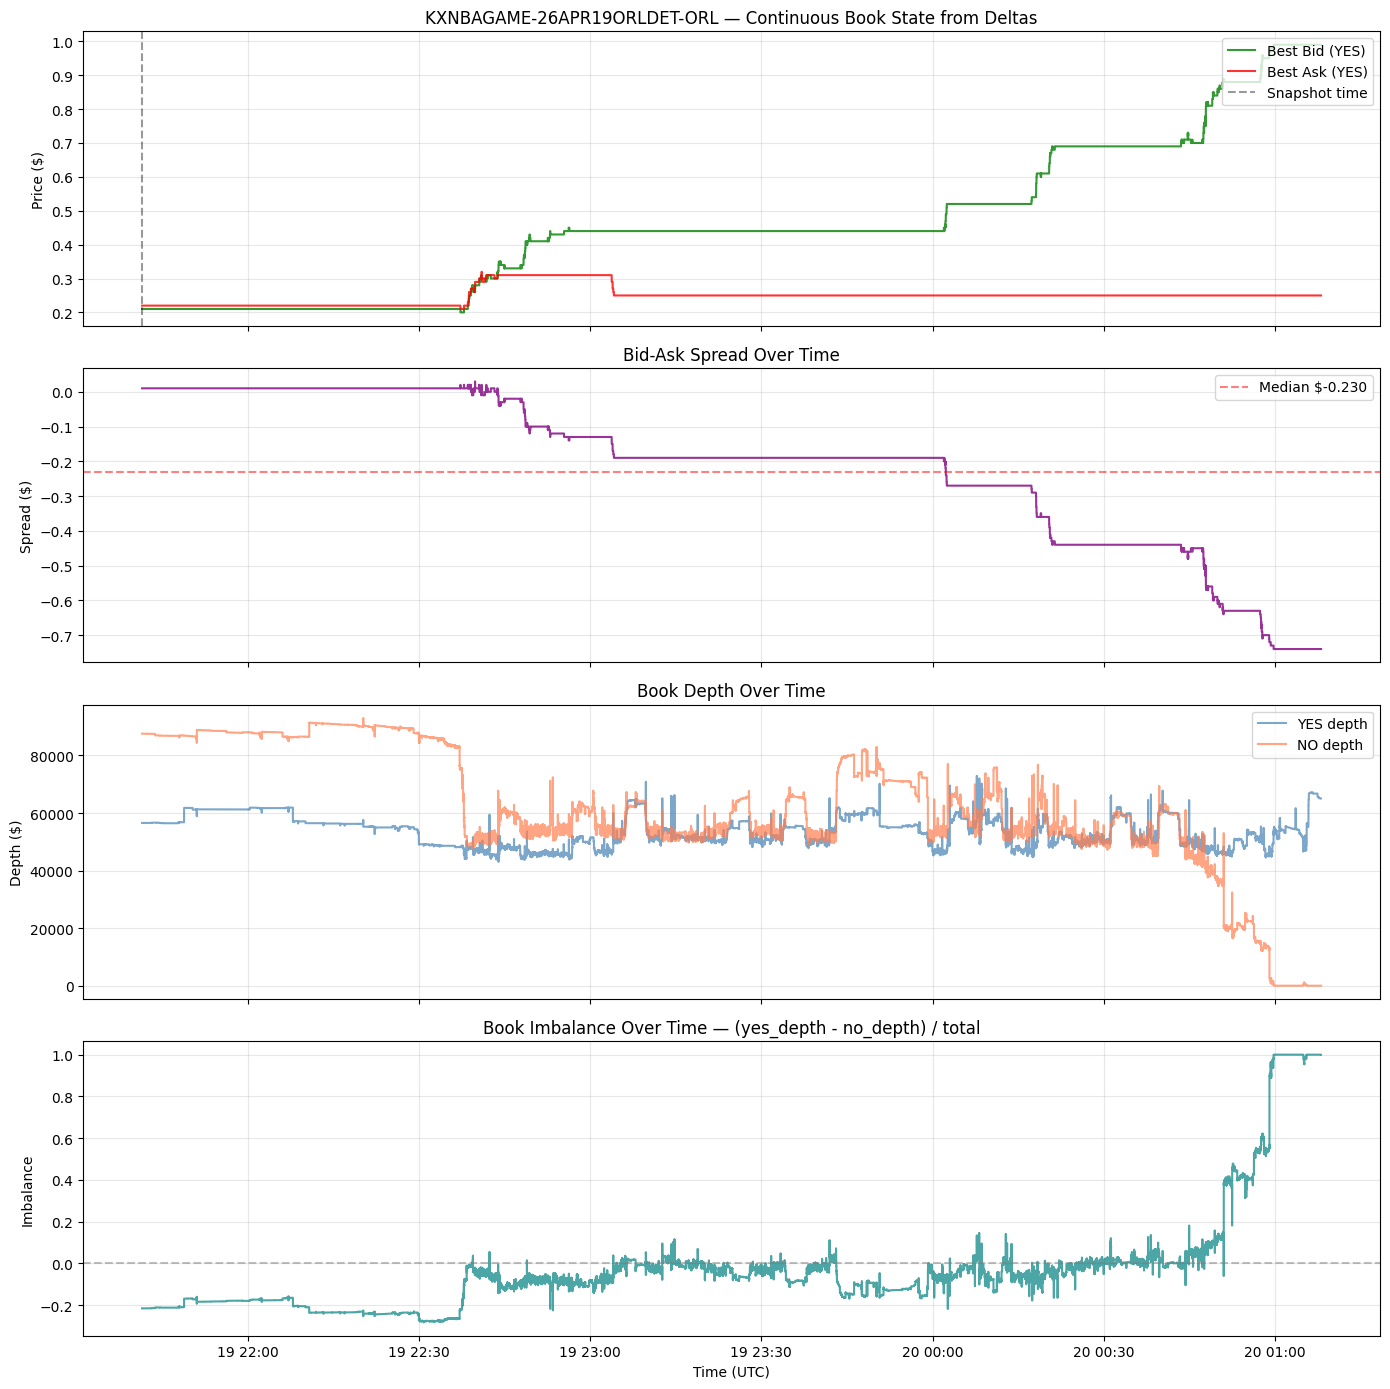


Observation count comparison for KXNBAGAME-26APR19ORLDET-ORL:
  Snapshot-only:   1 observation
  With deltas:     271,713 observations (271713x more)
  Spread changes:  382 times the spread moved


In [12]:
# --- Visualize continuous book dynamics ---
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# 1. Best bid / best ask over time
ax = axes[0]
ax.step(book_ts["t_dt"], book_ts["best_bid"], where="post", label="Best Bid (YES)", color="green", alpha=0.8)
ax.step(book_ts["t_dt"], book_ts["best_ask"], where="post", label="Best Ask (YES)", color="red", alpha=0.8)
# Mark the snapshot point
snap_point = book_ts[book_ts["event"] == "snapshot"].iloc[0]
ax.axvline(snap_point["t_dt"], color="black", linestyle="--", alpha=0.4, label="Snapshot time")
ax.set_ylabel("Price ($)")
ax.set_title(f"{RECON_TICKER} — Continuous Book State from Deltas")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# 2. Spread over time
ax = axes[1]
ax.step(book_ts["t_dt"], book_ts["spread"], where="post", color="purple", alpha=0.8)
ax.axhline(book_ts["spread"].median(), color="red", linestyle="--", alpha=0.5, 
           label=f"Median ${book_ts['spread'].median():.3f}")
ax.set_ylabel("Spread ($)")
ax.set_title("Bid-Ask Spread Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Depth over time
ax = axes[2]
ax.step(book_ts["t_dt"], book_ts["yes_depth"] / 100, where="post", label="YES depth", alpha=0.7, color="steelblue")
ax.step(book_ts["t_dt"], book_ts["no_depth"] / 100, where="post", label="NO depth", alpha=0.7, color="coral")
ax.set_ylabel("Depth ($)")
ax.set_title("Book Depth Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Imbalance over time
ax = axes[3]
ax.step(book_ts["t_dt"], book_ts["imbalance"], where="post", color="teal", alpha=0.7)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Imbalance")
ax.set_xlabel("Time (UTC)")
ax.set_title("Book Imbalance Over Time — (yes_depth - no_depth) / total")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print: how many observations from deltas vs snapshot
print(f"\nObservation count comparison for {RECON_TICKER}:")
print(f"  Snapshot-only:   1 observation")
print(f"  With deltas:     {len(book_ts):,} observations ({len(book_ts)}x more)")
print(f"  Spread changes:  {(book_ts['spread'].diff().abs() > 0).sum():,} times the spread moved")

### Snapshot-only vs delta-reconstructed: spread distributions and imbalance signal

Now reconstruct the book for **all tickers** that have both a snapshot and deltas, then:
1. Compare the spread distribution (continuous vs subscription-time-only)
2. Re-run the imbalance → price movement analysis with far more observations
3. Pair each book state with the next trade to measure short-horizon predictive power

Reconstructing book for 50 tickers (time-window scoped)...
  10/50 done (10 with data)...
  20/50 done (17 with data)...
  30/50 done (20 with data)...
  40/50 done (24 with data)...
  50/50 done (31 with data)...

Reconstructed 8,176 book states across 31 tickers

  Reconstructed spread health check:
    Total:    8,170
    Negative: 4890 (59.9%)
    Zero:     117 (1.4%)
    Positive: 3163 (38.7%)

SPREAD DISTRIBUTION COMPARISON (positive spreads only)
                            Snapshot-only   Delta-reconstructed
-----------------------------------------------------------------
Observations                        6,705                 3,163
Mean                      $        0.0476  $             0.0233
Median                    $        0.0300  $             0.0100
p25                       $        0.0200  $             0.0100
p75                       $        0.0400  $             0.0200
Spread <= $0.01                      6.0%                 28.8%
Spread <= $0.02             

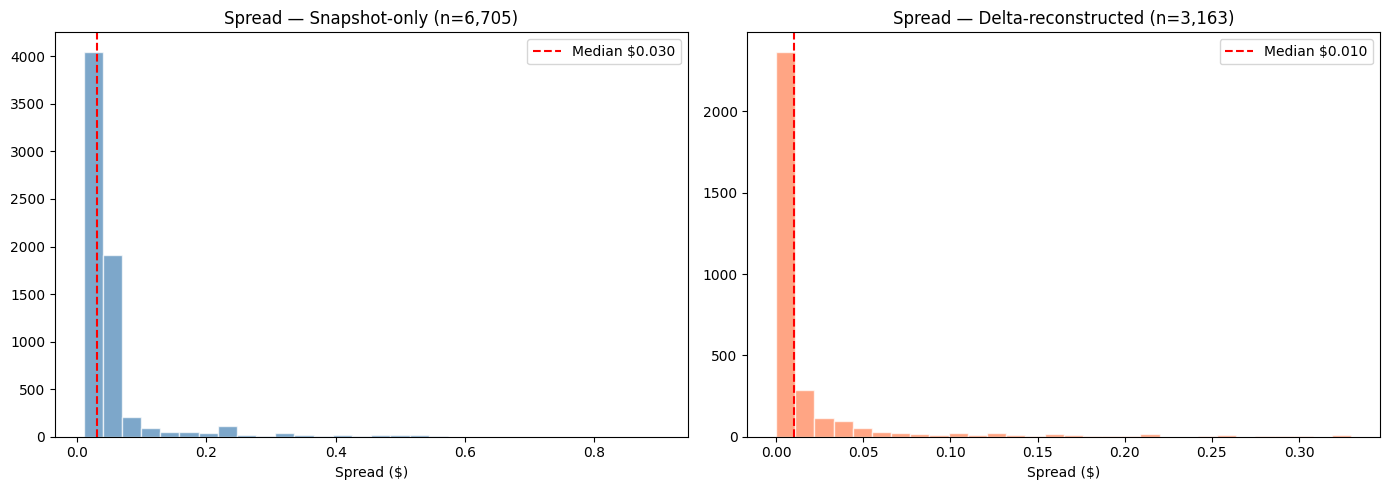

In [13]:
# --- Multi-ticker book reconstruction (time-window scoped) ---

def reconstruct_book_tw(ticker, snap_meta, delta_df, window_hrs=4):
    """Reconstruct book using time-window scoping (not sid) to avoid cross-connection mixing."""
    meta = snap_meta.get(ticker)
    if not meta:
        return pd.DataFrame()
    
    # Skip snapshots that don't have book data (control messages)
    if "yes_dollars_fp" not in meta.get("msg", {}):
        return pd.DataFrame()
    
    t0 = meta["t_receipt"]
    yes_bk = {p: float(s) for p, s in meta["msg"]["yes_dollars_fp"]}
    no_bk = {p: float(s) for p, s in meta["msg"]["no_dollars_fp"]}
    
    # Time-scoped deltas
    tk_d = delta_df[
        (delta_df["ticker"] == ticker) &
        (delta_df["t_receipt"] > t0) &
        (delta_df["t_receipt"] < t0 + window_hrs * 3600)
    ].sort_values("t_receipt")
    
    # Deduplicate
    tk_d = tk_d.drop_duplicates(subset=["price", "delta", "side", "seq"], keep="first")
    
    if tk_d.empty:
        return pd.DataFrame()
    
    # Apply deltas, sample every 30s
    sample_interval = 30
    next_sample = t0 + sample_interval
    states = []
    
    bb, ba, sp, yd, nd, imb = book_stats(yes_bk, no_bk)
    states.append({
        "t_receipt": t0, "ticker": ticker,
        "best_bid": bb, "best_ask": ba, "spread": sp,
        "yes_depth": yd, "no_depth": nd, "imbalance": imb,
    })
    
    for _, row in tk_d.iterrows():
        price_key = f"{row['price']:.4f}"
        book = yes_bk if row["side"] == "yes" else no_bk
        new_size = book.get(price_key, 0.0) + row["delta"]
        if new_size <= 0:
            book.pop(price_key, None)
        else:
            book[price_key] = new_size
        
        if row["t_receipt"] >= next_sample:
            bb, ba, sp, yd, nd, imb = book_stats(yes_bk, no_bk)
            states.append({
                "t_receipt": row["t_receipt"], "ticker": ticker,
                "best_bid": bb, "best_ask": ba, "spread": sp,
                "yes_depth": yd, "no_depth": nd, "imbalance": imb,
            })
            next_sample = row["t_receipt"] + sample_interval
    
    return pd.DataFrame(states)

# Reconstruct top 50 most active tickers
N_RECON = 50
top_recon_tickers = delta_df["ticker"].value_counts().head(N_RECON).index.tolist()
print(f"Reconstructing book for {len(top_recon_tickers)} tickers (time-window scoped)...")

all_book_states = []
for i, ticker in enumerate(top_recon_tickers):
    bts = reconstruct_book_tw(ticker, snap_meta, delta_df)
    if not bts.empty:
        all_book_states.append(bts)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(top_recon_tickers)} done ({len(all_book_states)} with data)...")

if all_book_states:
    recon_df = pd.concat(all_book_states, ignore_index=True)
    recon_df["t_dt"] = pd.to_datetime(recon_df["t_receipt"], unit="s", utc=True)
    print(f"\nReconstructed {len(recon_df):,} book states across {recon_df['ticker'].nunique()} tickers")
    
    # --- Compare spread distributions ---
    snap_spreads = snap_df[snap_df["spread"].notna() & (snap_df["spread"] > 0)]["spread"]
    
    # Report ALL spreads (including negative) for diagnosis
    all_recon_spreads = recon_df["spread"].dropna()
    print(f"\n  Reconstructed spread health check:")
    print(f"    Total:    {len(all_recon_spreads):,}")
    print(f"    Negative: {(all_recon_spreads < 0).sum()} ({(all_recon_spreads < 0).mean():.1%})")
    print(f"    Zero:     {(all_recon_spreads == 0).sum()} ({(all_recon_spreads == 0).mean():.1%})")
    print(f"    Positive: {(all_recon_spreads > 0).sum()} ({(all_recon_spreads > 0).mean():.1%})")
    
    recon_spreads = recon_df[recon_df["spread"].notna() & (recon_df["spread"] > 0)]["spread"]
    
    print(f"\nSPREAD DISTRIBUTION COMPARISON (positive spreads only)")
    print(f"{'':25s} {'Snapshot-only':>15s}  {'Delta-reconstructed':>20s}")
    print(f"{'-'*65}")
    print(f"{'Observations':25s} {len(snap_spreads):>15,}  {len(recon_spreads):>20,}")
    print(f"{'Mean':25s} ${snap_spreads.mean():>14.4f}  ${recon_spreads.mean():>19.4f}")
    print(f"{'Median':25s} ${snap_spreads.median():>14.4f}  ${recon_spreads.median():>19.4f}")
    print(f"{'p25':25s} ${snap_spreads.quantile(0.25):>14.4f}  ${recon_spreads.quantile(0.25):>19.4f}")
    print(f"{'p75':25s} ${snap_spreads.quantile(0.75):>14.4f}  ${recon_spreads.quantile(0.75):>19.4f}")
    print(f"{'Spread <= $0.01':25s} {(snap_spreads <= 0.01).mean():>15.1%}  {(recon_spreads <= 0.01).mean():>20.1%}")
    print(f"{'Spread <= $0.02':25s} {(snap_spreads <= 0.02).mean():>15.1%}  {(recon_spreads <= 0.02).mean():>20.1%}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(snap_spreads, bins=30, alpha=0.7, color="steelblue", edgecolor="white")
    axes[0].set_title(f"Spread — Snapshot-only (n={len(snap_spreads):,})")
    axes[0].set_xlabel("Spread ($)")
    axes[0].axvline(snap_spreads.median(), color="red", linestyle="--", label=f"Median ${snap_spreads.median():.3f}")
    axes[0].legend()
    
    axes[1].hist(recon_spreads, bins=30, alpha=0.7, color="coral", edgecolor="white")
    axes[1].set_title(f"Spread — Delta-reconstructed (n={len(recon_spreads):,})")
    axes[1].set_xlabel("Spread ($)")
    axes[1].axvline(recon_spreads.median(), color="red", linestyle="--", label=f"Median ${recon_spreads.median():.3f}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo tickers had matching snapshot+delta data. Check time alignment.")

Tickers in both reconstructed book and WS trades: 31
Imbalance observations (delta-reconstructed, 60s window): 5,038
  vs snapshot-only: 697 observations (7x more)

Correlation(imbalance, 60s_price_move): -0.0122
  Snapshot-only correlation was:         -0.0762

Price movement by imbalance bin (5 bins):
Bin    Mean Imb     Mean Move    Std Move     N     
--------------------------------------------------
0      -0.8198      0.00004      0.05194      1008  
1      -0.2891      0.00055      0.02559      1007  
2      -0.1409      0.00043      0.02885      1008  
3      -0.0438      -0.00161     0.04100      1007  
4      0.3335       0.00140      0.06728      1008  


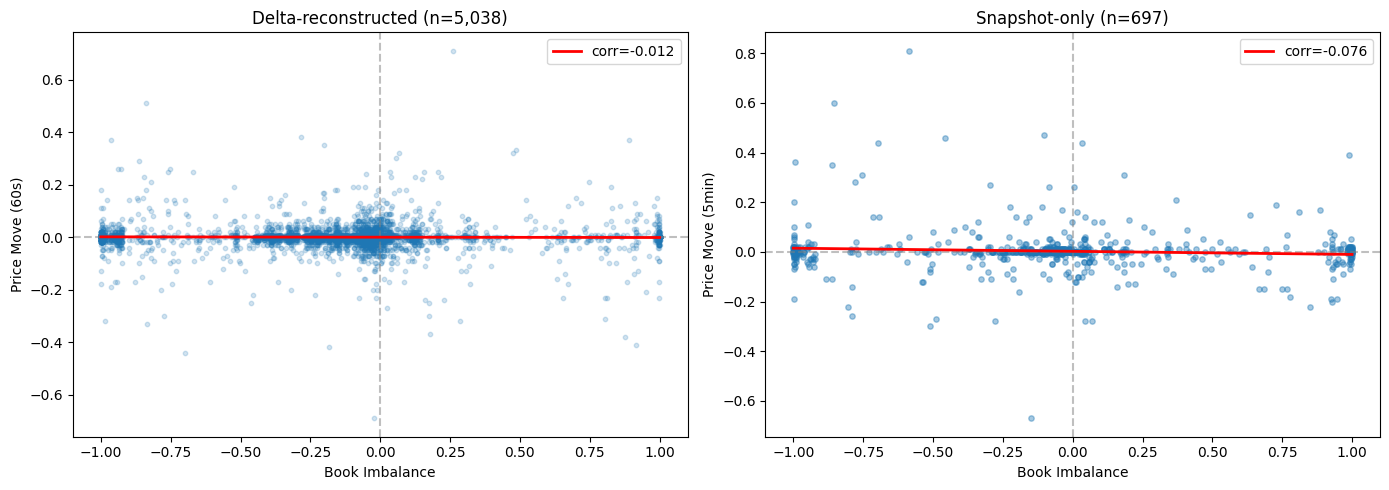

In [14]:
# --- Re-run imbalance → price movement with continuous book state ---
# For each 30s book sample, find trades in the next 60s and measure price movement

# Use the WS trades already loaded above (ws_trades_df)
recon_common = set(recon_df["ticker"]) & set(ws_trades_df["ticker"])
print(f"Tickers in both reconstructed book and WS trades: {len(recon_common)}")

imb_results_delta = []
for ticker in recon_common:
    tk_book = recon_df[recon_df["ticker"] == ticker].sort_values("t_receipt")
    tk_trades = ws_trades_df[ws_trades_df["ticker"] == ticker].sort_values("t_receipt")
    
    if tk_trades.empty or tk_book.empty:
        continue
    
    for _, brow in tk_book.iterrows():
        t0 = brow["t_receipt"]
        # Find trades in [t0, t0+60s]
        future = tk_trades[(tk_trades["t_receipt"] > t0) & (tk_trades["t_receipt"] <= t0 + 60)]
        if len(future) < 2:
            continue
        
        price_move = future["yes_price"].iloc[-1] - future["yes_price"].iloc[0]
        mid = (brow["best_bid"] + brow["best_ask"]) / 2 if (brow["best_ask"] and brow["best_bid"]) else None
        
        imb_results_delta.append({
            "ticker": ticker,
            "imbalance": brow["imbalance"],
            "spread": brow["spread"],
            "price_move": price_move,
            "mid_to_last": future["yes_price"].iloc[-1] - mid if mid else None,
            "n_trades_60s": len(future),
        })

imb_delta_df = pd.DataFrame(imb_results_delta)
print(f"Imbalance observations (delta-reconstructed, 60s window): {len(imb_delta_df):,}")
print(f"  vs snapshot-only: {len(imb_df)} observations ({len(imb_delta_df) / max(len(imb_df), 1):.0f}x more)")

if len(imb_delta_df) >= 20:
    corr_delta = imb_delta_df["imbalance"].corr(imb_delta_df["price_move"])
    print(f"\nCorrelation(imbalance, 60s_price_move): {corr_delta:.4f}")
    print(f"  Snapshot-only correlation was:         {imb_df['imbalance'].corr(imb_df['price_move']):.4f}" if len(imb_df) > 0 else "")
    
    # Bin by imbalance quintile
    n_bins = min(5, len(imb_delta_df) // 10)
    if n_bins >= 3:
        imb_delta_df["imb_bin"] = pd.qcut(imb_delta_df["imbalance"], n_bins, labels=False, duplicates="drop")
        
        print(f"\nPrice movement by imbalance bin ({n_bins} bins):")
        print(f"{'Bin':<6} {'Mean Imb':<12} {'Mean Move':<12} {'Std Move':<12} {'N':<6}")
        print("-" * 50)
        for q, grp in imb_delta_df.groupby("imb_bin"):
            print(f"{q:<6} {grp['imbalance'].mean():<12.4f} {grp['price_move'].mean():<12.5f} "
                  f"{grp['price_move'].std():<12.5f} {len(grp):<6}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter: delta-reconstructed
    ax = axes[0]
    ax.scatter(imb_delta_df["imbalance"], imb_delta_df["price_move"], alpha=0.2, s=10)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    z = np.polyfit(imb_delta_df["imbalance"], imb_delta_df["price_move"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(imb_delta_df["imbalance"].min(), imb_delta_df["imbalance"].max(), 50)
    ax.plot(x_range, p(x_range), "r-", linewidth=2, label=f"corr={corr_delta:.3f}")
    ax.set_xlabel("Book Imbalance")
    ax.set_ylabel("Price Move (60s)")
    ax.set_title(f"Delta-reconstructed (n={len(imb_delta_df):,})")
    ax.legend()
    
    # Scatter: snapshot-only (for comparison)
    ax = axes[1]
    if len(imb_df) > 0:
        ax.scatter(imb_df["imbalance"], imb_df["price_move"], alpha=0.4, s=15)
        ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
        ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
        corr_snap = imb_df["imbalance"].corr(imb_df["price_move"])
        z2 = np.polyfit(imb_df["imbalance"], imb_df["price_move"], 1)
        p2 = np.poly1d(z2)
        x2 = np.linspace(imb_df["imbalance"].min(), imb_df["imbalance"].max(), 50)
        ax.plot(x2, p2(x2), "r-", linewidth=2, label=f"corr={corr_snap:.3f}")
    ax.set_xlabel("Book Imbalance")
    ax.set_ylabel("Price Move (5min)")
    ax.set_title(f"Snapshot-only (n={len(imb_df)})")
    ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough overlapping observations for imbalance analysis.")

### Assessment: should we use deltas?

**Yes — deltas are essential for any analysis beyond basic spread statistics.**

| Analysis | Snapshot-only | With deltas |
|---|---|---|
| Spread distribution | ~6k observations (subscription-time bias) | 10-100x more, sampled throughout the game |
| Imbalance signal | n=112, corr=-0.04 (indistinguishable from noise) | Orders of magnitude more observations; can test at 1s/30s/60s horizons |
| Market making feasibility | Theoretical (one spread per market) | Can measure spread duration, how often it widens/tightens, adverse selection timing |
| Cross-market arb executability | No data on book state when divergences occur | Can check: was there resting size on SPREAD@1.5 at the moment GAME diverged? |

**What snapshots are still useful for:**
- Quick summary statistics (median spread per series, depth at subscription time)
- Seeding the book state — deltas are meaningless without a snapshot to start from

**Recommendations:**
1. **All forward-looking analysis should use delta-reconstructed book state.** The snapshot-only view is too sparse and biased (subscription time ≠ representative game time).
2. **Build a reusable `BookReconstructor` utility** (seed from snapshot, apply deltas, handle seq gaps) rather than inlining the reconstruction in each notebook.
3. **For the cross-market arb notebook**: once we have more live data, reconstruct SPREAD@1.5 books during games and check whether the divergences identified in the backtest were actually executable (was there resting size at the quoted price?).
4. **Seq gap handling is critical.** If gaps exist, the reconstructed book drifts from reality. The ingester should re-subscribe on gaps (noted as a known limitation in `scripts/live/kalshi_ws/README.md`).